# Sequential Repeater Analysis Plots

All plots use seaborn styling. Run the **Setup** cell first, then each plot cell independently.

## Setup — build all four networks

In [2]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as ticker
import seaborn as sns

from sequential_repeaters import (
    RepeaterParams, QuantumRepeaterNetwork,
    build_s2_graph, binary_entropy, build_graph
)

# ── global plot style ────────────────────────────────────────────────────────
sns.set_theme(style='whitegrid', context='notebook', font_scale=1.1)
PALETTE = sns.color_palette('tab10')

# ── default physical parameters ──────────────────────────────────────────────
def make_params(**overrides):
    """Return a RepeaterParams with standard values, optionally overridden."""
    p = RepeaterParams()
    p.p_det     = 0.95
    p.alpha     = 0.18
    p.q_0       = 0.01
    p.nu        = 1e9
    p.R_dark    = 100
    p.delta_det = 100e-12
    p.p_pair    = 0.05
    p.eta_c     = 0.8
    p.P_BSM     = 0.5
    for k, v in overrides.items():
        setattr(p, k, v)
    return p

N    = 1000
BETA = 2.6261
MU   = 0.0233

# ── build graphs (slow — run once) ───────────────────────────────────────────
print('Building S2 city ...')
A_city,    dist_city,    coords_city    = build_s2_graph(N, BETA, MU, scale='city')
print('Building S2 country ...')
A_country, dist_country, coords_country = build_s2_graph(N, BETA, MU, scale='country')
print('Building S2 europe ...')
A_europe,  dist_europe,  coords_europe  = build_s2_graph(N, BETA, MU, scale='europe')
print('Building custom graph ...')
A_custom,  dist_custom                  = build_graph(5, 6)   # adjust args as needed
print('Done.')

# ── build network objects ────────────────────────────────────────────────────
params = make_params()

net_city    = QuantumRepeaterNetwork(params, A_city,    dist_city,    coords_city,
                                     architecture='node', scale='city')
net_country = QuantumRepeaterNetwork(params, A_country, dist_country, coords_country,
                                     architecture='node', scale='country')
net_europe  = QuantumRepeaterNetwork(params, A_europe,  dist_europe,  coords_europe,
                                     architecture='node', scale='europe')
net_custom  = QuantumRepeaterNetwork(params, A_custom,  dist_custom,  coords=None,
                                     architecture='node', scale=1.0)

NETWORKS = [
    ('S2 city',    net_city,    PALETTE[0]),
    ('S2 country', net_country, PALETTE[1]),
    ('S2 europe',  net_europe,  PALETTE[2]),
    ('Custom',     net_custom,  PALETTE[3]),
]

SOURCE = 0
print('All networks ready.')

Building S2 city ...
Building S2 country ...
Building S2 europe ...
Building custom graph ...
Done.
All networks ready.


## Synthetic path helpers

These functions compute QBER and SKR analytically for a chain of `n_hops` equal
links spanning `total_dist_km`, without needing a graph object.  Used by Plots 3a/3b
and the QBER contributions plot.

The `architecture` parameter controls how transmissions are assigned per link:
- `'node'`     — source at one end; one arm travels the full link, the other zero.
- `'midpoint'` — source at the centre; both arms travel half the link (symmetric).

In [20]:
def _link_transmissions(params, link_dist_km, architecture):
    """
    Return (eta_A, eta_B) for a single link of length link_dist_km.

    Parameters
    ----------
    params        : RepeaterParams
    link_dist_km  : float   physical length of one link [km]
    architecture  : 'node' or 'midpoint'
    """
    p = params
    if architecture == 'midpoint':
        # Source at centre — both photons travel half the link
        eta = p.eta_c * p.p_det * 10 ** (-p.alpha * (link_dist_km / 2) / 10)
        return eta, eta
    elif architecture == 'node':
        # Source at one node — one photon stays local (eta_A=eta_c*p_det),
        # the other travels the full link
        eta_A = p.eta_c * p.p_det   # zero fibre distance
        eta_B = p.eta_c * p.p_det * 10 ** (-p.alpha * link_dist_km / 10)
        return eta_A, eta_B
    else:
        raise ValueError("architecture must be 'node' or 'midpoint'")


def _link_qber_components(params, link_dist_km, architecture):
    """
    Return the four additive contributions to the per-link QBER numerator,
    plus the denominator (p_true + p_acc), as a dict.

    The per-link QBER is:
        Q_link = (baseline + multiphoton + dc_mixed + dc_both) / (p_true + p_acc)

    where:
        baseline    = p_true * q_0
        multiphoton = p_true * p_pair / 2
        dc_mixed    = 0.5 * p_pair * (eta_A*(1-eta_B) + eta_B*(1-eta_A)) * p_dc
        dc_both     = 0.5 * p_dc^2
        p_true      = p_pair * eta_A * eta_B
        p_acc       = p_pair*eta_A*(1-eta_B)*p_dc + p_pair*eta_B*(1-eta_A)*p_dc + p_dc^2

    Returns
    -------
    dict with keys: 'baseline', 'multiphoton', 'dc_mixed', 'dc_both', 'denominator'
    """
    p = params
    p_dc = p.R_dark * p.delta_det
    eta_A, eta_B = _link_transmissions(p, link_dist_km, architecture)

    p_true   = p.p_pair * eta_A * eta_B
    p_acc    = (p.p_pair * eta_A * (1 - eta_B) * p_dc
                + p.p_pair * eta_B * (1 - eta_A) * p_dc
                + p_dc ** 2)
    denom    = p_true + p_acc

    baseline    = p_true * p.q_0
    multiphoton = p_true * p.p_pair / 2
    dc_mixed    = 0.5 * (p.p_pair * eta_A * (1 - eta_B)
                         + p.p_pair * eta_B * (1 - eta_A)) * p_dc
    dc_both     = 0.5 * p_dc ** 2

    return {
        'baseline':    baseline,
        'multiphoton': multiphoton,
        'dc_mixed':    dc_mixed,
        'dc_both':     dc_both,
        'denominator': denom,
    }


def _synthetic_qber(params, total_dist_km, n_hops, architecture='midpoint'):
    """
    QBER for a synthetic chain of n_hops equal links spanning total_dist_km.

    Parameters
    ----------
    params        : RepeaterParams
    total_dist_km : float
    n_hops        : int
    architecture  : 'node' or 'midpoint'

    Returns
    -------
    float  QBER in [0, 0.5], or np.nan if no signal
    """
    link_dist = total_dist_km / n_hops
    c = _link_qber_components(params, link_dist, architecture)

    if c['denominator'] == 0:
        return np.nan

    Q_link = (c['baseline'] + c['multiphoton'] + c['dc_mixed'] + c['dc_both']) \
             / c['denominator']
    W_link  = 1 - 2 * Q_link
    W_total = W_link ** n_hops   # visibility degrades multiplicatively
    return (1 - W_total) / 2


def _synthetic_skr(params, total_dist_km, n_hops, architecture='midpoint'):
    """
    SKR for a synthetic chain of n_hops equal links spanning total_dist_km.

    Parameters
    ----------
    params        : RepeaterParams
    total_dist_km : float
    n_hops        : int
    architecture  : 'node' or 'midpoint'

    Returns
    -------
    float  SKR [bit/s], or np.nan if no signal
    """
    p = params
    link_dist = total_dist_km / n_hops
    eta_A, eta_B = _link_transmissions(p, link_dist, architecture)
    p_ent = p.p_pair * eta_A * eta_B

    if p_ent <= 0:
        return np.nan

    # Sequential time recurrence (same formula as QuantumRepeaterNetwork.sequential_time)
    T = 1.0 / p_ent
    for _ in range(n_hops - 1):
        T = (T + 1.0 / p_ent) / p.P_BSM

    Q = _synthetic_qber(params, total_dist_km, n_hops, architecture)
    if np.isnan(Q):
        return np.nan

    R_ent = 0.5 * p.nu / T
    return R_ent * (1 - 2 * binary_entropy(Q))


print('Synthetic helpers defined.')

Synthetic helpers defined.


## Plot 1 — SKR vs P_BSM (4 subplots, adaptive hop lines)

Each subplot shows one network topology.  Within each subplot, one line per hop
count shows the best SKR achievable using a path of **exactly** that many hops,
as P_BSM varies from 0 to 1.  Hop counts are adaptive: only those that actually
exist in the graph (up to `max_hops`) are shown.

  S2 city ...
  S2 country ...
  S2 europe ...
  Custom ...


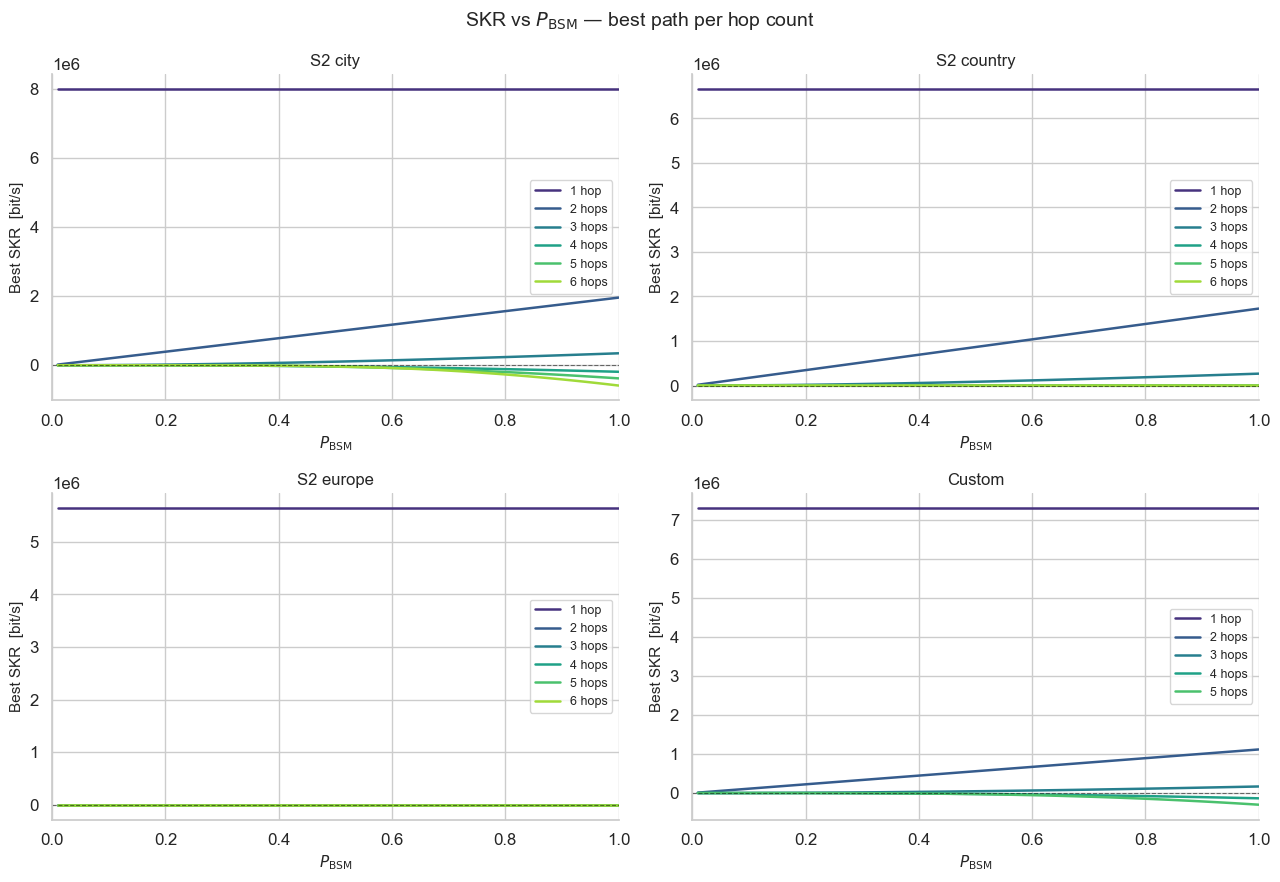

In [21]:
def _paths_by_hopcount(net, source):
    """
    Return a dict mapping hop_count -> list of paths with that hop count,
    using the current (default P_BSM) optimal paths as a path catalogue.

    We use the default-P_BSM Dijkstra to discover which paths exist, then
    group them by length.  For each P_BSM sweep we reuse these same path
    structures but recompute metrics with updated params.
    """
    _, paths = net.optimal_path(source)
    paths.pop(source, None)

    by_hops = {}
    for dest, path in paths.items():
        n = len(path) - 1
        by_hops.setdefault(n, []).append(path)
    return by_hops


def plot_skr_vs_pbsm_subplots(networks, source=0, n_points=50, max_hops=6):
    """
    4-subplot figure: SKR vs P_BSM, one subplot per network.
    Within each subplot, one line per hop count (adaptive, up to max_hops).

    For each P_BSM value the SKR is computed for every path in the catalogue
    for that hop count; the maximum is plotted.

    Parameters
    ----------
    networks  : list of (label, QuantumRepeaterNetwork, colour)  — colour unused here
    source    : int
    n_points  : int   number of P_BSM values
    max_hops  : int   maximum hop count to display
    """
    pbsm_vals   = np.linspace(0.01, 1.0, n_points)
    hop_palette = sns.color_palette('viridis', max_hops)

    fig, axes = plt.subplots(2, 2, figsize=(13, 9), sharey=False)
    axes = axes.flatten()

    for ax, (label, net, _) in zip(axes, networks):
        print(f'  {label} ...')

        # Catalogue of paths grouped by hop count (fixed topology)
        by_hops = _paths_by_hopcount(net, source)
        hop_counts = sorted(h for h in by_hops if h <= max_hops)

        for hop_n in hop_counts:
            path_list = by_hops[hop_n]
            best_skrs = []

            for pbsm in pbsm_vals:
                p_new = make_params(P_BSM=pbsm)
                net_tmp = QuantumRepeaterNetwork(
                    p_new, net.A, net.dist, net.coords,
                    architecture=net.architecture,
                    scale=net.scale_km,
                )
                # Best SKR among all paths with exactly hop_n hops
                skr_candidates = [net_tmp.secret_key_rate(p) for p in path_list]
                best_skrs.append(max(skr_candidates))

            colour = hop_palette[hop_n - 1]
            ax.plot(pbsm_vals, best_skrs, color=colour, linewidth=1.8,
                    label=f'{hop_n} hop{"s" if hop_n > 1 else ""}')

        ax.axhline(0, color='black', linewidth=0.8, linestyle='--', alpha=0.5)
        ax.set_title(label, fontsize=12)
        ax.set_xlabel(r'$P_{\mathrm{BSM}}$', fontsize=11)
        ax.set_ylabel('Best SKR  [bit/s]', fontsize=11)
        ax.legend(fontsize=9, frameon=True)
        ax.set_xlim(0, 1)
        sns.despine(ax=ax)

    fig.suptitle('SKR vs $P_{\\mathrm{BSM}}$ — best path per hop count', fontsize=14)
    plt.tight_layout()
    plt.savefig('plots/plot1_skr_vs_pbsm.pdf', bbox_inches='tight')
    plt.show()


plot_skr_vs_pbsm_subplots(NETWORKS, source=SOURCE)

## Plot 2 — QBER vs number of hops (alpha = 0)

With fibre loss disabled (alpha = 0) QBER depends only on dark counts and intrinsic
errors, independent of distance.  One representative path per hop count is taken
from the S2 city graph.

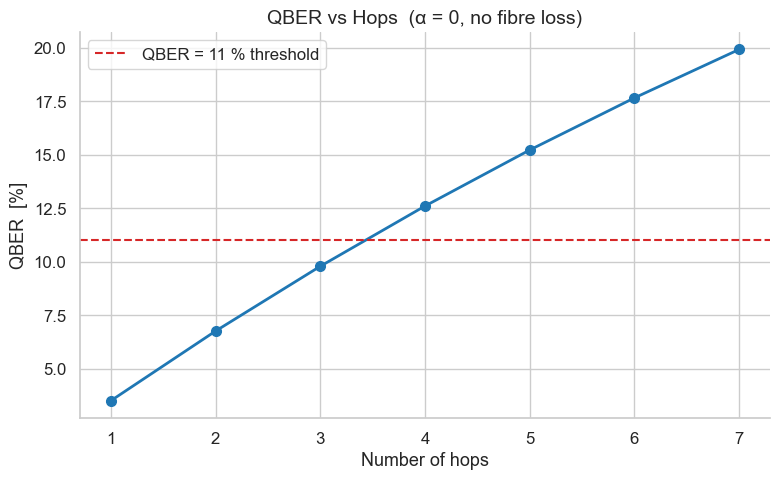

In [22]:
def plot_qber_vs_hops(net, source=0, max_hops=None):
    """
    QBER vs hop count with alpha=0.  One representative path per hop count.

    Parameters
    ----------
    net      : QuantumRepeaterNetwork
    source   : int
    max_hops : int or None
    """
    QBER_THRESHOLD = 0.11

    p_no_loss = make_params(alpha=0.0)
    net_nl = QuantumRepeaterNetwork(
        p_no_loss, net.A, net.dist, net.coords,
        architecture=net.architecture, scale=net.scale_km,
    )

    _, paths = net_nl.optimal_path(source)
    paths.pop(source, None)

    # One representative path per hop count
    rep_by_hops = {}
    for path in paths.values():
        n = len(path) - 1
        if n not in rep_by_hops:
            rep_by_hops[n] = path

    hop_counts = sorted(rep_by_hops)
    if max_hops is not None:
        hop_counts = [h for h in hop_counts if h <= max_hops]

    qbers = [net_nl.qber(rep_by_hops[h]) * 100 for h in hop_counts]

    fig, ax = plt.subplots(figsize=(8, 5))
    ax.plot(hop_counts, qbers, marker='o', linewidth=2,
            color=PALETTE[0], markersize=7)
    ax.axhline(QBER_THRESHOLD * 100, color=PALETTE[3], linewidth=1.5,
               linestyle='--', label='QBER = 11 % threshold')
    ax.set_xlabel('Number of hops', fontsize=13)
    ax.set_ylabel('QBER  [%]', fontsize=13)
    ax.set_title('QBER vs Hops  (α = 0, no fibre loss)', fontsize=14)
    ax.set_xticks(hop_counts)
    ax.legend(frameon=True)
    ax.set_xlim(min(hop_counts) - 0.3, max(hop_counts) + 0.3)
    sns.despine()
    plt.tight_layout()
    plt.savefig('plots/plot2_qber_vs_hops.pdf', bbox_inches='tight')
    plt.show()


plot_qber_vs_hops(net_city, source=SOURCE)

## Plot 3a — QBER vs hops at fixed total distance

Synthetic equal-hop paths.  Each line is a different total distance; hops split
it equally.  Shows the trade-off between adding repeaters and accumulated QBER.

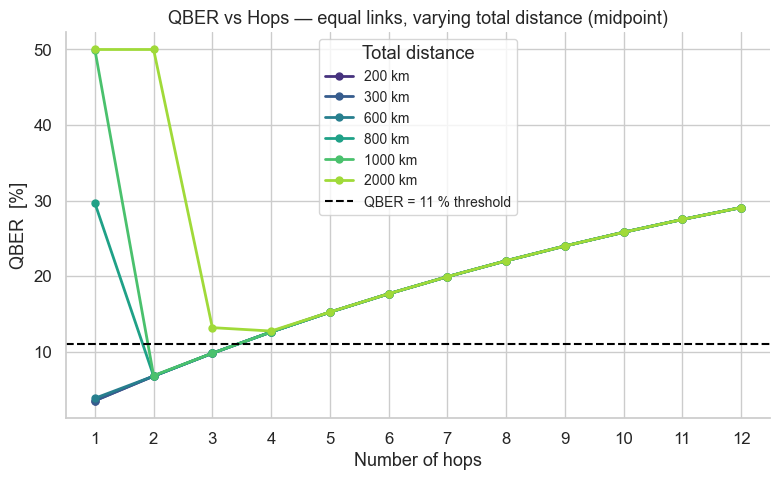

In [27]:
def plot_qber_vs_hops_fixed_dist(
        params,
        distances_km = [200, 300, 600, 800, 1000, 2000],
        max_hops=12,
        architecture='midpoint'):
    """
    QBER vs number of hops for several fixed total distances.

    Parameters
    ----------
    params        : RepeaterParams
    distances_km  : iterable of float
    max_hops      : int
    architecture  : 'node' or 'midpoint'
    """
    QBER_THRESHOLD = 0.11
    hop_range = range(1, max_hops + 1)
    palette   = sns.color_palette('viridis', len(distances_km))

    fig, ax = plt.subplots(figsize=(8, 5))

    for dist_km, colour in zip(distances_km, palette):
        qbers = [
            _synthetic_qber(params, dist_km, h, architecture) * 100
            for h in hop_range
        ]
        ax.plot(list(hop_range), qbers, marker='o', linewidth=2,
                color=colour, markersize=5, label=f'{dist_km} km')

    ax.axhline(QBER_THRESHOLD * 100, color='black', linewidth=1.5,
               linestyle='--', label='QBER = 11 % threshold')
    ax.set_xlabel('Number of hops', fontsize=13)
    ax.set_ylabel('QBER  [%]', fontsize=13)
    ax.set_title(
        f'QBER vs Hops — equal links, varying total distance ({architecture})',
        fontsize=13)
    ax.set_xticks(list(hop_range))
    ax.legend(title='Total distance', frameon=True, fontsize=10)
    ax.set_xlim(0.5, max_hops + 0.5)
    sns.despine()
    plt.tight_layout()
    plt.savefig('plots/plot3a_qber_vs_hops_fixed_dist.pdf', bbox_inches='tight')
    plt.show()


plot_qber_vs_hops_fixed_dist(params)

## Plot 3a (extra) — QBER error contributions vs hops

Stacked area chart showing which physical process dominates the QBER at each hop
count, for a single fixed total distance.  The four contributions are:

| Term | Physical origin |
|---|---|
| Baseline | Intrinsic source imperfection (q₀) |
| Multi-photon | Accidental coincidences from pair statistics |
| Dark counts (mixed) | One real photon + one dark count |
| Dark counts (both) | Both detectors fire from dark counts |

The y-axis shows each term's contribution to the numerator of Q_link, normalised
by the denominator — so contributions sum to Q_link for a single link.

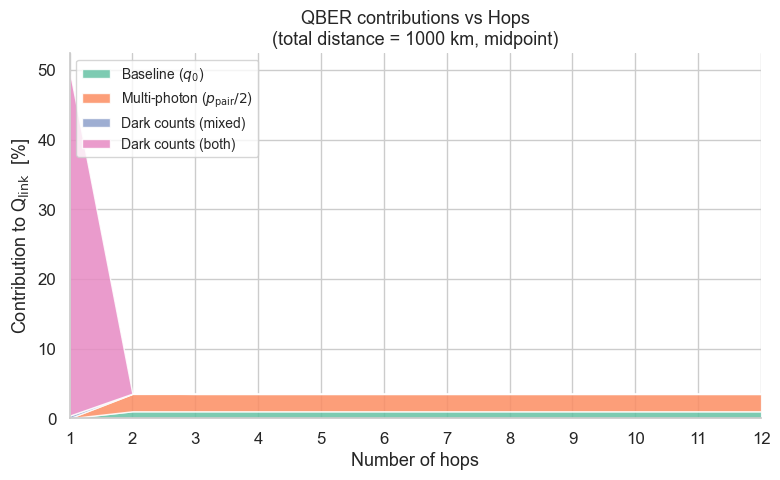

In [25]:
def plot_qber_contributions(
        params,
        total_dist_km=20,
        max_hops=12,
        architecture='midpoint'):
    """
    Stacked area chart of the four QBER contributions vs hop count,
    for a fixed total distance.

    Each contribution is expressed as a fraction of the per-link denominator
    (p_true + p_acc), so the stack sums to Q_link (the per-link QBER).
    This is the per-link picture; the end-to-end QBER accumulates non-linearly
    via the Werner visibility product.

    Parameters
    ----------
    params        : RepeaterParams
    total_dist_km : float   fixed total path distance [km]
    max_hops      : int
    architecture  : 'node' or 'midpoint'
    """
    hop_range = list(range(1, max_hops + 1))

    baseline    = []
    multiphoton = []
    dc_mixed    = []
    dc_both     = []

    for h in hop_range:
        link_dist = total_dist_km / h
        c = _link_qber_components(params, link_dist, architecture)
        d = c['denominator']
        if d == 0:
            baseline.append(np.nan)
            multiphoton.append(np.nan)
            dc_mixed.append(np.nan)
            dc_both.append(np.nan)
        else:
            baseline.append(c['baseline']    / d * 100)
            multiphoton.append(c['multiphoton'] / d * 100)
            dc_mixed.append(c['dc_mixed']    / d * 100)
            dc_both.append(c['dc_both']      / d * 100)

    contrib_palette = sns.color_palette('Set2', 4)
    labels = ['Baseline ($q_0$)', 'Multi-photon ($p_{\\mathrm{pair}}/2$)',
              'Dark counts (mixed)', 'Dark counts (both)']
    data   = [baseline, multiphoton, dc_mixed, dc_both]

    fig, ax = plt.subplots(figsize=(8, 5))

    ax.stackplot(hop_range, data, labels=labels,
                 colors=contrib_palette, alpha=0.85)

    ax.set_xlabel('Number of hops', fontsize=13)
    ax.set_ylabel('Contribution to Q$_{\\mathrm{link}}$  [%]', fontsize=13)
    ax.set_title(
        f'QBER contributions vs Hops\n'
        f'(total distance = {total_dist_km} km, {architecture})',
        fontsize=13)
    ax.set_xticks(hop_range)
    ax.legend(loc='upper left', frameon=True, fontsize=10)
    ax.set_xlim(1, max_hops)
    sns.despine()
    plt.tight_layout()
    plt.savefig('plots/plot3a_qber_contributions.pdf', bbox_inches='tight')
    plt.show()

plot_qber_contributions(params, total_dist_km=1000)

## Plot 3b — SKR vs hops at fixed total distance

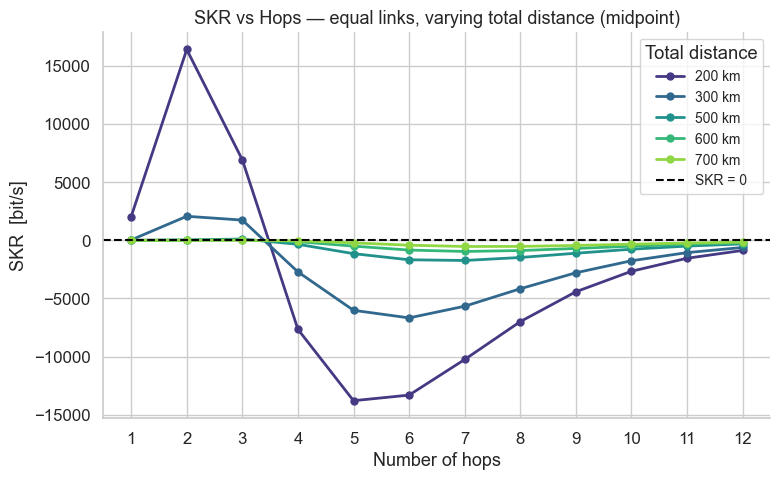

In [26]:
def plot_skr_vs_hops_fixed_dist(
        params,
        distances_km = [200, 300, 500, 600, 700],
        max_hops=12,
        architecture='midpoint'):
    """
    SKR vs number of hops for several fixed total distances.

    Parameters
    ----------
    params        : RepeaterParams
    distances_km  : iterable of float
    max_hops      : int
    architecture  : 'node' or 'midpoint'
    """
    hop_range = range(1, max_hops + 1)
    palette   = sns.color_palette('viridis', len(distances_km))

    fig, ax = plt.subplots(figsize=(8, 5))

    for dist_km, colour in zip(distances_km, palette):
        skrs = [
            _synthetic_skr(params, dist_km, h, architecture)
            for h in hop_range
        ]
        ax.plot(list(hop_range), skrs, marker='o', linewidth=2,
                color=colour, markersize=5, label=f'{dist_km} km')

    ax.axhline(0, color='black', linewidth=1.5,
               linestyle='--', label='SKR = 0')
    ax.set_xlabel('Number of hops', fontsize=13)
    ax.set_ylabel('SKR  [bit/s]', fontsize=13)
    ax.set_title(
        f'SKR vs Hops — equal links, varying total distance ({architecture})',
        fontsize=13)
    ax.set_xticks(list(hop_range))
    ax.legend(title='Total distance', frameon=True, fontsize=10)
    ax.set_xlim(0.5, max_hops + 0.5)
    sns.despine()
    plt.tight_layout()
    plt.savefig('plots/plot3b_skr_vs_hops_fixed_dist.pdf', bbox_inches='tight')
    plt.show()


plot_skr_vs_hops_fixed_dist(params)